<table width=100%>
<tr>
    <td><h1 style="text-align: left; font-size:300%;">
        ML2026 - Homework
    </h1></td>
    <div style="text-align: right">
    <b> Machine Learning 2026</b> <br>
    <td width="100px"> 
        
</tr>
</table>

### Packages

In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [2]:
import numpy as np
np.random.seed(0)
import matplotlib
import matplotlib.pyplot as plt
from cycler import cycler

from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Task 1
_Perform preliminary analysis of the data. For instance, but not limited to, visualizing samples, identifying if features are correlated, determining which are most correlated with the target class, and inspecting the distribution of samples among classes. We want to recover the data for the Exit Rate variable. Train a regressor to predict this variable’s values given the remaining variables. Compare different regression algorithms for this task, and perform feature selection. Since this feature is also missing in the test set, use only the training data for this step and use robust evaluation techniques to compare algorithms._

## Preliminary analysis of the data

### Data preprocessing

In [4]:
data = pd.read_csv("data/online_shoppers_intention.csv")
train_data = pd.read_csv("data/training_set_online_shoppers_intention.csv")
test_data = pd.read_csv("data/test_set_online_shoppers_intention.csv")

In [5]:
data.head()
train_data.head()
test_data.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


,Unnamed: 0,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,3496,0,0.000000,0,0.0,5,19.000000,0.000000,0.080000,0.000000,0.6,May,2,2,1,3,Returning_Visitor,False,False
1,9415,5,158.700000,0,0.0,51,1364.266667,0.007692,0.011987,0.000000,0.0,Nov,3,2,3,2,Returning_Visitor,True,False
2,9419,7,87.916667,1,0.0,46,1621.025379,0.004082,0.020544,6.023523,0.0,Dec,1,1,3,2,Returning_Visitor,False,False
3,3837,1,4.000000,0,0.0,37,1296.942857,0.013889,NaN,0.000000,0.8,May,2,2,4,2,Returning_Visitor,False,False
4,7305,2,132.400000,0,0.0,11,296.300000,0.000000,NaN,0.000000,0.0,Sep,2,4,3,2,New_Visitor,False,False


,Unnamed: 0,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0,0.0,0,0.0,1,0.000000,0.200000,NaN,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,3,0,0.0,0,0.0,2,2.666667,0.050000,NaN,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
2,5,0,0.0,0,0.0,19,154.216667,0.015789,0.024561,0.0,0.0,Feb,2,2,1,3,Returning_Visitor,False,False
3,12,0,0.0,0,0.0,7,280.500000,0.000000,0.028571,0.0,0.0,Feb,1,1,1,3,Returning_Visitor,False,False
4,14,0,0.0,0,0.0,2,68.000000,0.000000,NaN,0.0,0.0,Feb,3,2,3,3,Returning_Visitor,False,False


In [6]:
test_data.head()

,Unnamed: 0,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0,0.0,0,0.0,1,0.000000,0.200000,NaN,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,3,0,0.0,0,0.0,2,2.666667,0.050000,NaN,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
2,5,0,0.0,0,0.0,19,154.216667,0.015789,0.024561,0.0,0.0,Feb,2,2,1,3,Returning_Visitor,False,False
3,12,0,0.0,0,0.0,7,280.500000,0.000000,0.028571,0.0,0.0,Feb,1,1,1,3,Returning_Visitor,False,False
4,14,0,0.0,0,0.0,2,68.000000,0.000000,NaN,0.0,0.0,Feb,3,2,3,3,Returning_Visitor,False,False


Since I want to remove unnamed column (ID perhaps):

In [7]:
train_data.drop(["Unnamed: 0"], inplace = True, axis = 1)
test_data.drop(["Unnamed: 0"], inplace = True, axis = 1)

In [8]:
train_data.head()
test_data.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.000000,0,0.0,5,19.000000,0.000000,0.080000,0.000000,0.6,May,2,2,1,3,Returning_Visitor,False,False
1,5,158.700000,0,0.0,51,1364.266667,0.007692,0.011987,0.000000,0.0,Nov,3,2,3,2,Returning_Visitor,True,False
2,7,87.916667,1,0.0,46,1621.025379,0.004082,0.020544,6.023523,0.0,Dec,1,1,3,2,Returning_Visitor,False,False
3,1,4.000000,0,0.0,37,1296.942857,0.013889,NaN,0.000000,0.8,May,2,2,4,2,Returning_Visitor,False,False
4,2,132.400000,0,0.0,11,296.300000,0.000000,NaN,0.000000,0.0,Sep,2,4,3,2,New_Visitor,False,False


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,NaN,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,2.666667,0.050000,NaN,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
2,0,0.0,0,0.0,19,154.216667,0.015789,0.024561,0.0,0.0,Feb,2,2,1,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,7,280.500000,0.000000,0.028571,0.0,0.0,Feb,1,1,1,3,Returning_Visitor,False,False
4,0,0.0,0,0.0,2,68.000000,0.000000,NaN,0.0,0.0,Feb,3,2,3,3,Returning_Visitor,False,False


## Explorative Analysis

I want to explore the data types in my dataframe

In [9]:
exp_data = train_data.copy()
exp_data.dtypes

Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                 object
Weekend                       bool
Revenue                       bool
dtype: object

In [10]:
exp_data.columns

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType',
       'Weekend', 'Revenue'],
      dtype='object')

Few columns must be categorical since treating these variables as integers would imply an order or a magnitude that does not exist in the real context.

In [11]:
categorical_columns = ["OperatingSystems", "Browser", "Region", "TrafficType", "VisitorType"]
exp_data[categorical_columns] = exp_data[categorical_columns].astype("category")
month_order = ['Feb','Mar','May','June','Jul','Aug','Sep','Oct','Nov','Dec']
month_dtype = pd.CategoricalDtype(categories=month_order, ordered=True)
exp_data['Month'] = exp_data['Month'].astype(month_dtype)

In [12]:
exp_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9248 entries, 0 to 9247
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   Administrative           9248 non-null   int64   
 1   Administrative_Duration  9248 non-null   float64 
 2   Informational            9248 non-null   int64   
 3   Informational_Duration   9248 non-null   float64 
 4   ProductRelated           9248 non-null   int64   
 5   ProductRelated_Duration  9248 non-null   float64 
 6   BounceRates              9248 non-null   float64 
 7   ExitRates                6466 non-null   float64 
 8   PageValues               9248 non-null   float64 
 9   SpecialDay               9248 non-null   float64 
 10  Month                    9248 non-null   category
 11  OperatingSystems         9248 non-null   category
 12  Browser                  9248 non-null   category
 13  Region                   9248 non-null   category
 14  TrafficT

In [13]:
exp_data.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay
count,9248.000000,9248.000000,9248.000000,9248.000000,9248.000000,9248.000000,9248.000000,6466.000000,9248.000000,9248.000000
mean,2.303417,79.244607,0.502054,34.903589,31.695718,1183.552836,0.022647,0.042791,5.841185,0.062522
std,3.306724,172.311739,1.252054,140.233919,44.062244,1791.438690,0.049182,0.048164,18.448440,0.200413
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,183.612500,0.000000,0.014286,0.000000,0.000000
50%,1.000000,7.000000,0.000000,0.000000,18.000000,593.399405,0.003279,0.025000,0.000000,0.000000
75%,4.000000,91.000000,0.000000,0.000000,38.000000,1456.401191,0.017124,0.050000,0.000000,0.000000
max,27.000000,2720.500000,14.000000,2256.916667,584.000000,29970.465970,0.200000,0.200000,361.763742,1.000000


Checking for NA in each column (axis=0)

In [14]:
np.sum(exp_data.isna(), axis=0)

Administrative                0
Administrative_Duration       0
Informational                 0
Informational_Duration        0
ProductRelated                0
ProductRelated_Duration       0
BounceRates                   0
ExitRates                  2782
PageValues                    0
SpecialDay                    0
Month                         0
OperatingSystems              0
Browser                       0
Region                        0
TrafficType                   0
VisitorType                   0
Weekend                       0
Revenue                       0
dtype: int64

In [15]:
categorical_columns = ["OperatingSystems", "Browser", "Region", "TrafficType", "VisitorType", "Month"]
corr = exp_data.drop(categorical_columns, axis=1).corr()
corr

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Weekend,Revenue
Administrative,1.000000,0.611851,0.375773,0.258137,0.419721,0.380945,-0.224850,-0.309846,0.094717,-0.102648,0.028321,0.134150
Administrative_Duration,0.611851,1.000000,0.289336,0.218854,0.259107,0.303871,-0.145781,-0.207051,0.067182,-0.080183,0.014885,0.091469
Informational,0.375773,0.289336,1.000000,0.616967,0.352429,0.377018,-0.116810,-0.156937,0.042454,-0.052272,0.034639,0.093716
Informational_Duration,0.258137,0.218854,0.616967,1.000000,0.266616,0.320617,-0.075360,-0.103809,0.028986,-0.032154,0.028703,0.066165
ProductRelated,0.419721,0.259107,0.352429,0.266616,1.000000,0.873362,-0.208201,-0.294423,0.053836,-0.032640,0.021780,0.162163
ProductRelated_Duration,0.380945,0.303871,0.377018,0.320617,0.873362,1.000000,-0.198554,-0.269676,0.055034,-0.045060,0.010219,0.164373
BounceRates,-0.224850,-0.145781,-0.116810,-0.075360,-0.208201,-0.198554,1.000000,0.912628,-0.121093,0.074986,-0.050657,-0.152728
ExitRates,-0.309846,-0.207051,-0.156937,-0.103809,-0.294423,-0.269676,0.912628,1.000000,-0.175136,0.107706,-0.069067,-0.208109
PageValues,0.094717,0.067182,0.042454,0.028986,0.053836,0.055034,-0.121093,-0.175136,1.000000,-0.064241,0.004976,0.485376
SpecialDay,-0.102648,-0.080183,-0.052272,-0.032154,-0.032640,-0.045060,0.074986,0.107706,-0.064241,1.000000,-0.017286,-0.082262


<Axes: >

Text(0.5, 1.0, 'Feature Correlation Matrix')

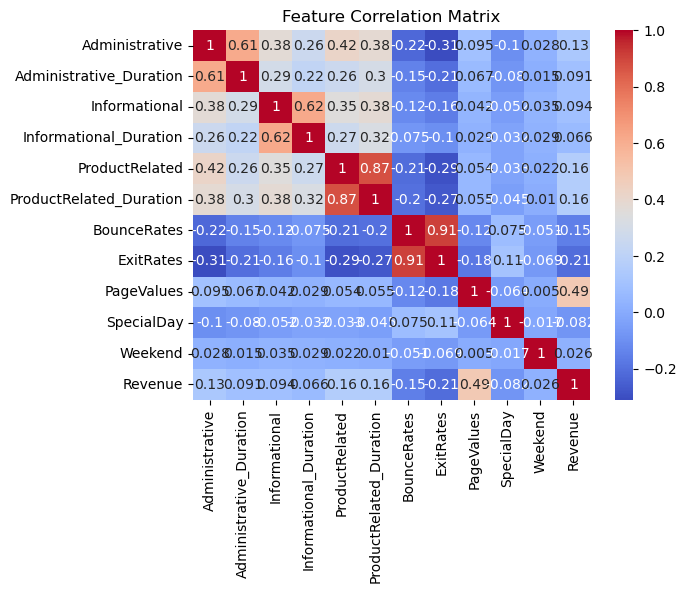

In [16]:
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

Looking at the heat map, we can see that ``Revenue`` and ``PageValues`` seems to be moderately correlated. 
\
Other features the pairs ExitRate-BounceRate, ProductRelated-ProductRelated_Duration, Informational-Informational-Duration I mean are obviously correlated since they are referring to the same events

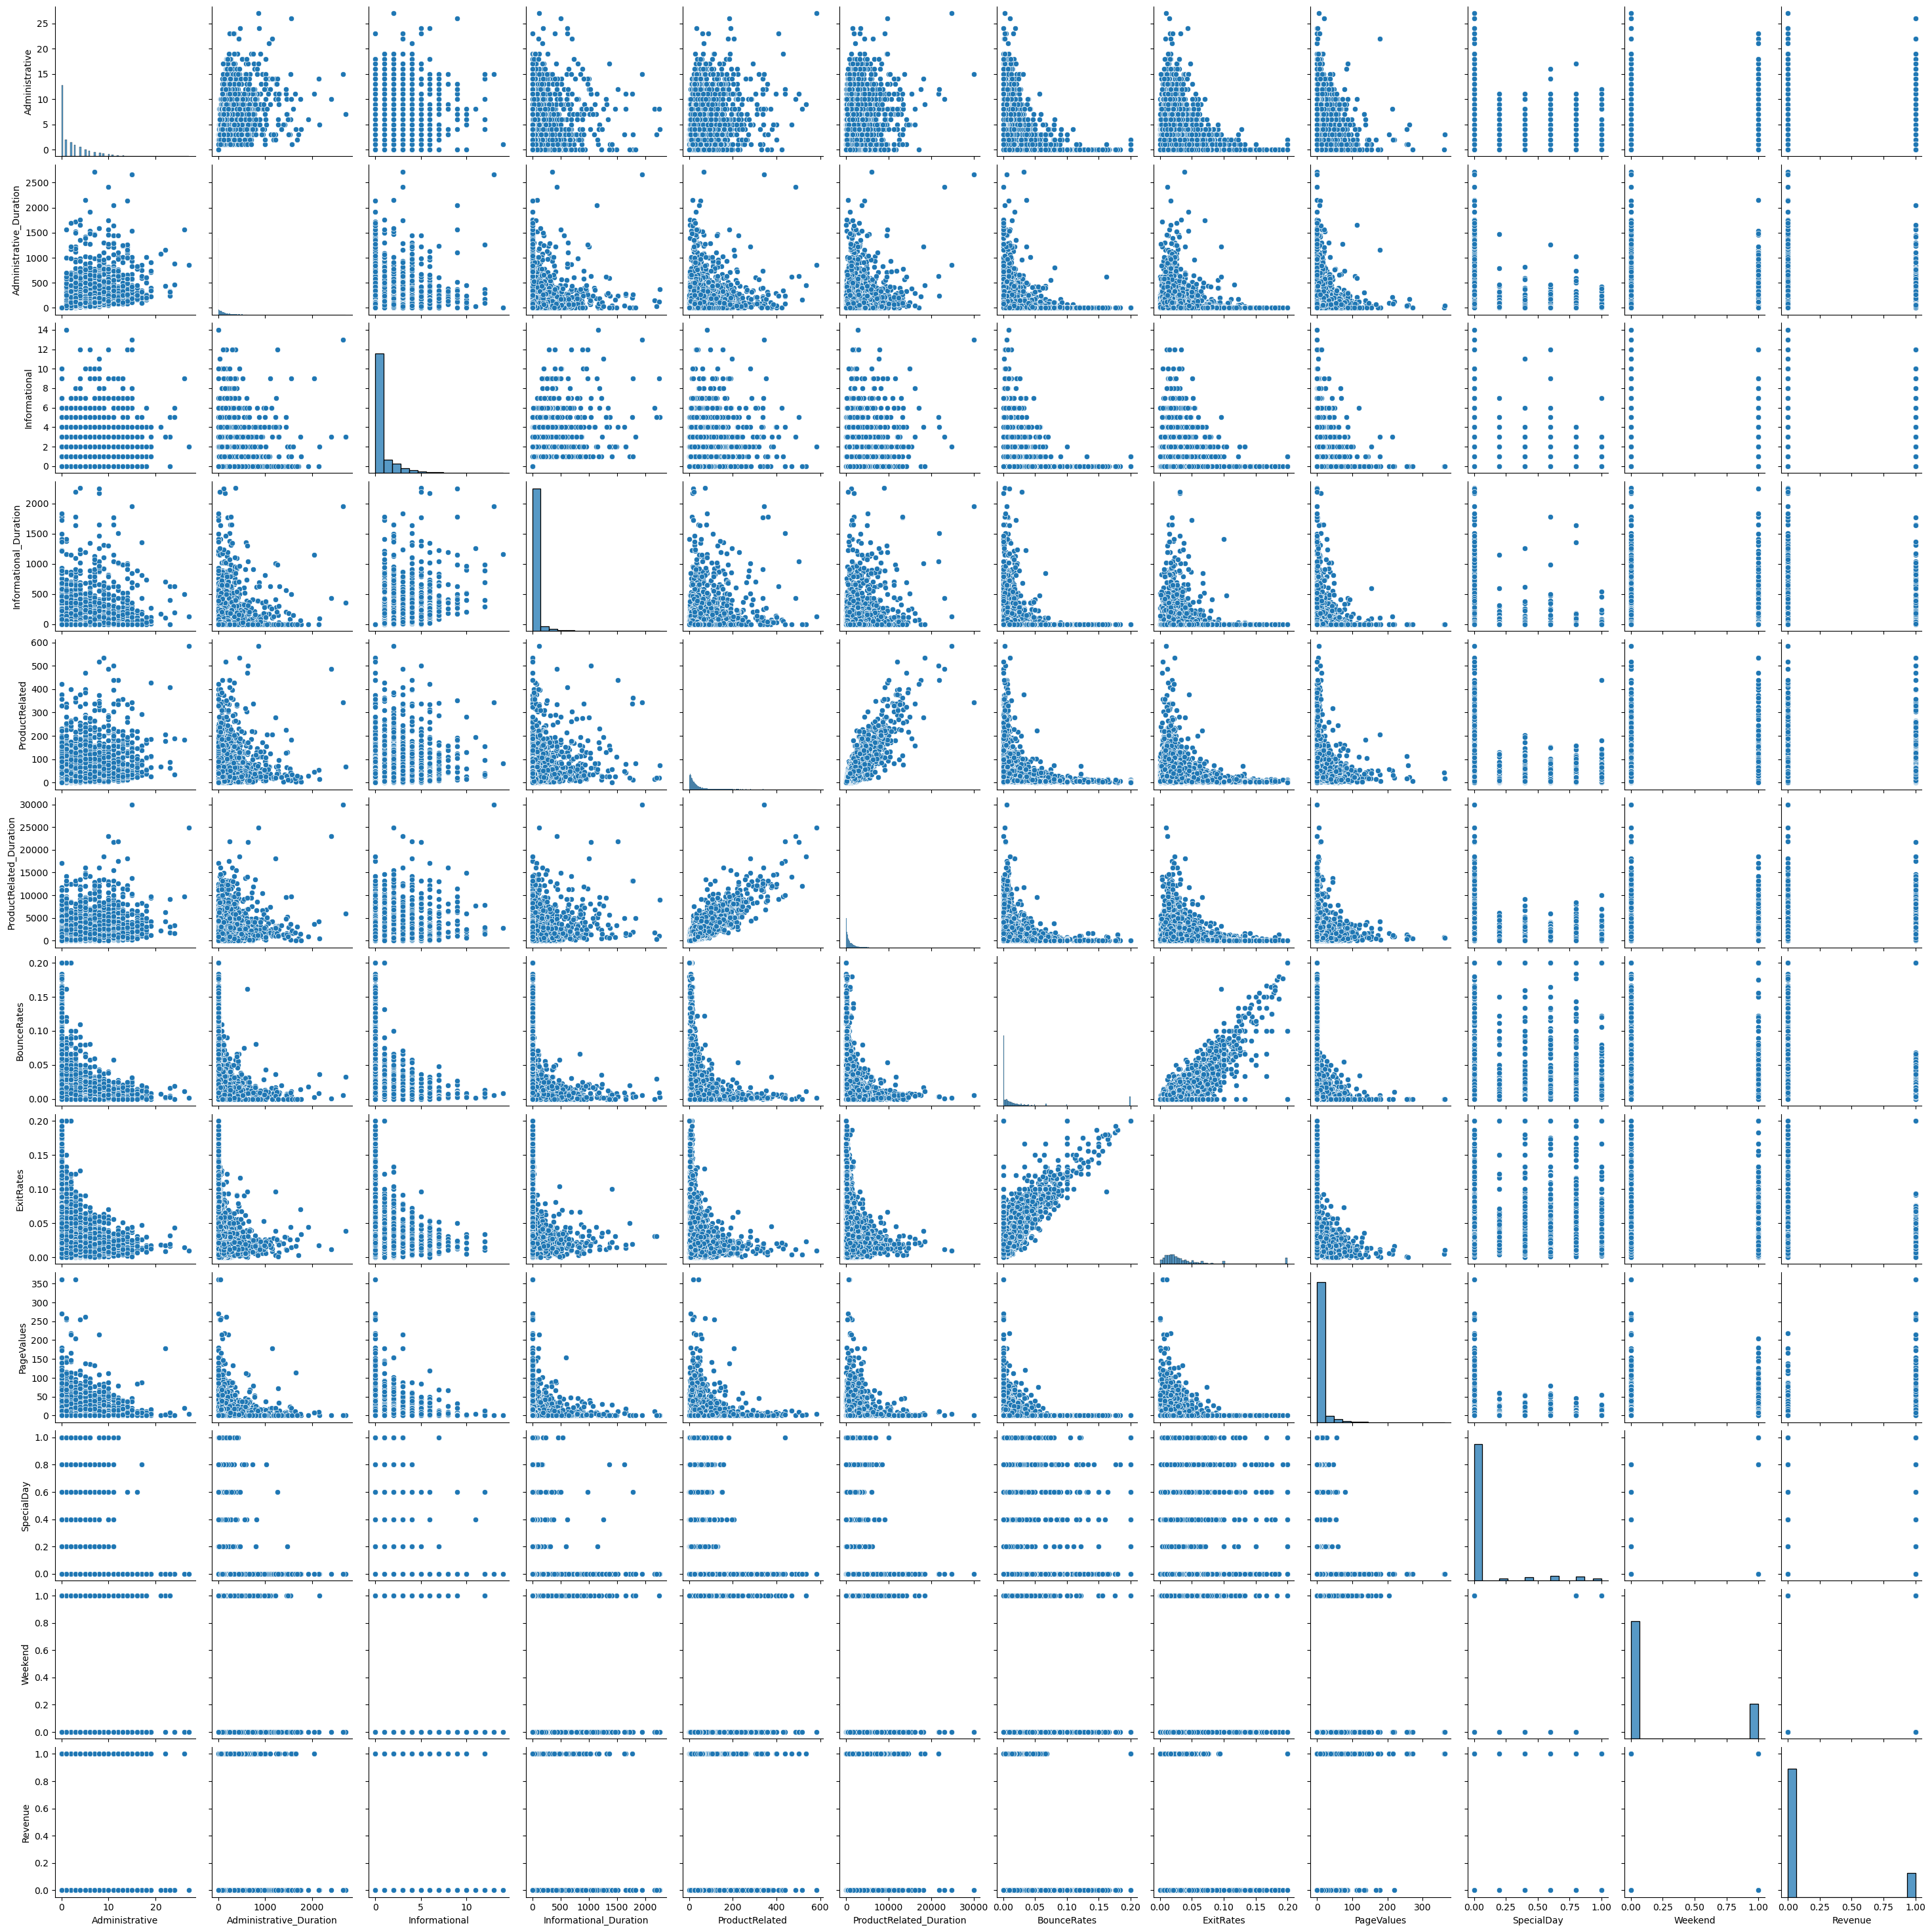

In [17]:
sns.pairplot(exp_data, height=2.5)
plt.show()

In [18]:
exp_data['Revenue'].value_counts()

Revenue
False    7807
True     1441
Name: count, dtype: int64

<Axes: xlabel='Revenue', ylabel='count'>

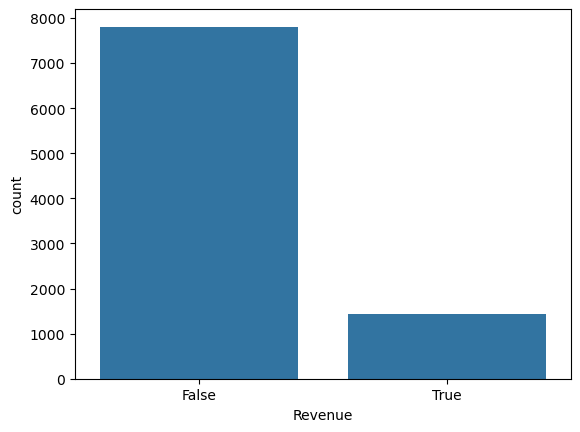

In [19]:
sns.countplot(x='Revenue', data=exp_data)
plt.show()

The target variable ``Revenue`` exhibits a clear class imbalance, with False representing the majority (7807 samples) and True the minority (1441 samples). Given this distribution, accuracy is not a reliable metric. Therefore, I will prioritize metrics like the F1-Score and utilize stratified splitting to maintain class proportions across training and test sets, ensuring the model is evaluated fairly on its ability to detect purchasing intent.

### Distribution of Features

### Categorical Variables

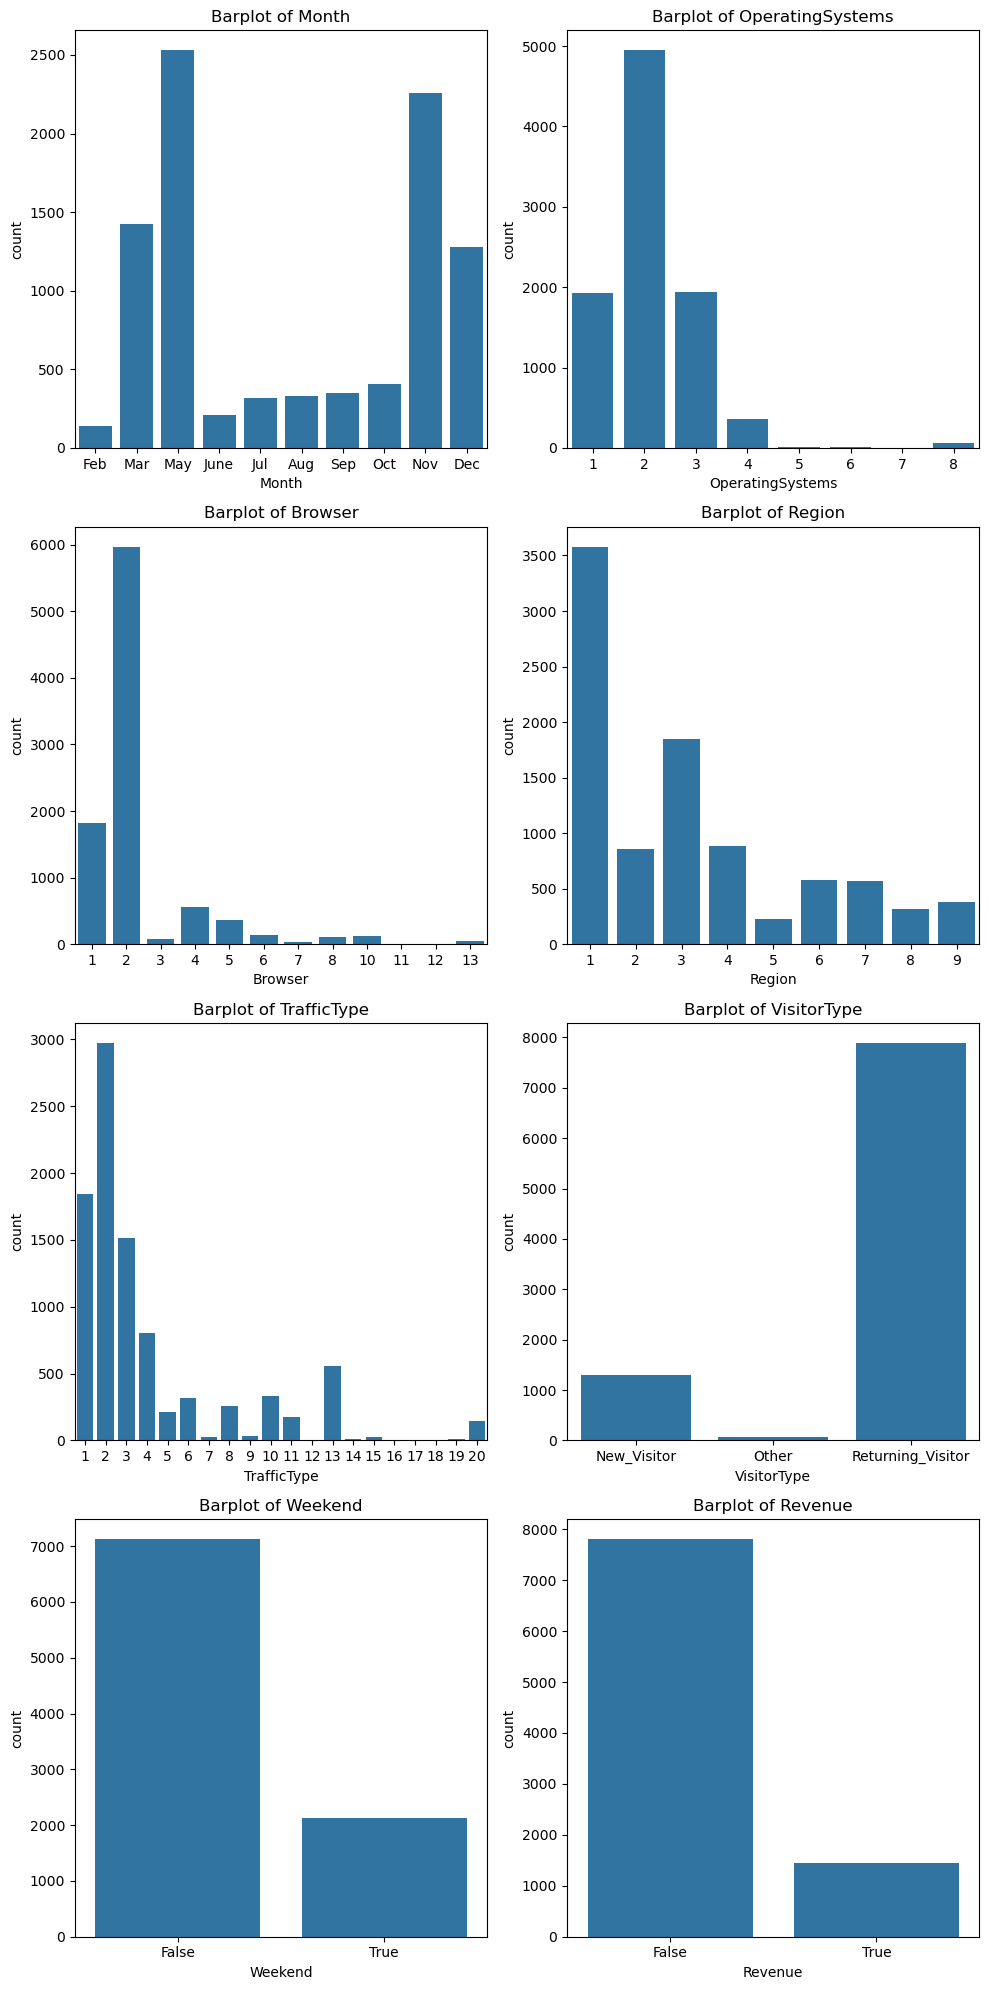

In [20]:
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(10, 20))
categoricals = ['Month','OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType','Weekend', 'Revenue']
for name in enumerate(categoricals):
    i, name = name
    sns.countplot(data=exp_data, x=name, ax=axes[i // 2, i % 2])
    axes[i // 2, i % 2].set_title("Barplot of {}".format(name))

plt.tight_layout()
plt.show();

### Continuous Features

<Axes: xlabel='Revenue', ylabel='Administrative'>

Text(0.5, 1.0, 'Boxplot of Administrative')

<Axes: xlabel='Revenue', ylabel='Administrative_Duration'>

Text(0.5, 1.0, 'Boxplot of Administrative_Duration')

<Axes: xlabel='Revenue', ylabel='Informational'>

...

Text(0.5, 1.0, 'Boxplot of BounceRates')

<Axes: xlabel='Revenue', ylabel='ExitRates'>

Text(0.5, 1.0, 'Boxplot of ExitRates')

<Axes: xlabel='Revenue', ylabel='PageValues'>

Text(0.5, 1.0, 'Boxplot of PageValues')

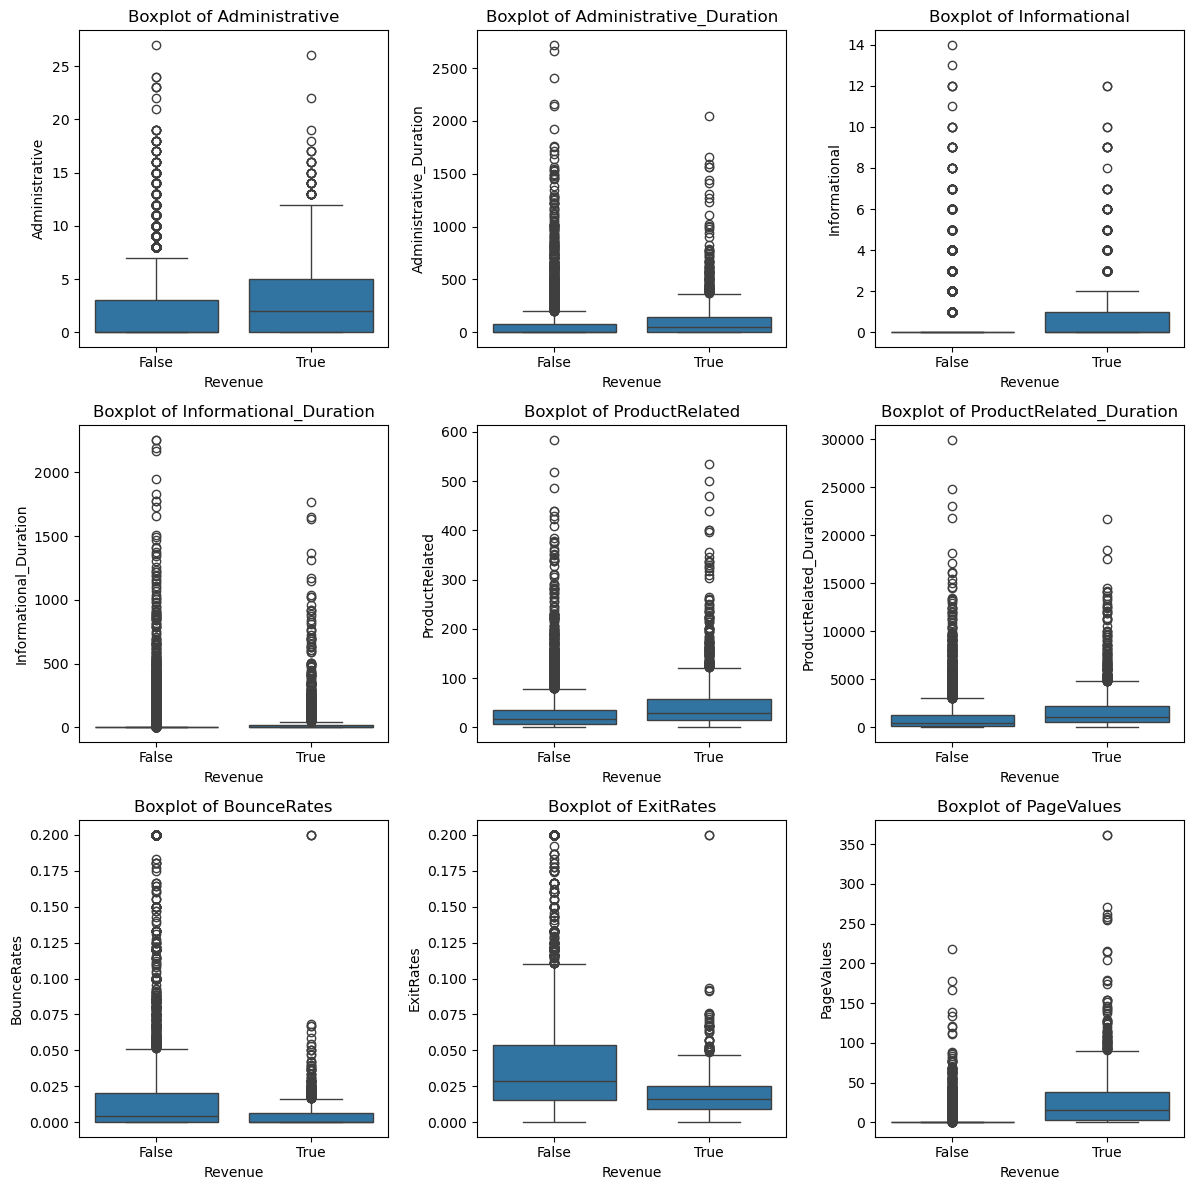

In [21]:
#boxplot a continuos variable and consider if it has outliers and everything: 
continuous = ['Administrative', 'Administrative_Duration', 'Informational',
             'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
             'BounceRates', 'ExitRates', 'PageValues']

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(12, 12))
plt.subplots_adjust(hspace=0.4)

for i, name in enumerate(continuous):
    row = i // 3
    col = i % 3
    ax = axes[row, col]
    sns.boxplot(data=exp_data, x="Revenue", y=name, ax=ax)
    ax.set_title("Boxplot of {}".format(name))

plt.tight_layout()
plt.show()

## Exit Rate Variable

How many missing values do I have in my training set and in my test set?

In [22]:
train_data.isna().sum()
test_data.isna().sum()

train_NA = train_data['ExitRates'].isna().sum()/len(train_data) *100
test_NA = test_data['ExitRates'].isna().sum()/len(test_data) *100
print(f'\nPercentage of NA in training set : {train_NA}\nPercentage of NA in test set : {test_NA}')

Administrative                0
Administrative_Duration       0
Informational                 0
Informational_Duration        0
ProductRelated                0
ProductRelated_Duration       0
BounceRates                   0
ExitRates                  2782
PageValues                    0
SpecialDay                    0
Month                         0
OperatingSystems              0
Browser                       0
Region                        0
TrafficType                   0
VisitorType                   0
Weekend                       0
Revenue                       0
dtype: int64

Administrative               0
Administrative_Duration      0
Informational                0
Informational_Duration       0
ProductRelated               0
ProductRelated_Duration      0
BounceRates                  0
ExitRates                  917
PageValues                   0
SpecialDay                   0
Month                        0
OperatingSystems             0
Browser                      0
Region                       0
TrafficType                  0
VisitorType                  0
Weekend                      0
Revenue                      0
dtype: int64


Percentage of NA in training set : 30.08217993079585
Percentage of NA in test set : 29.753406878650228


In [23]:
train_data.groupby(train_data['ExitRates'].isna())['Revenue'].mean()

ExitRates
False    0.156047
True     0.155284
Name: Revenue, dtype: float64

### Regression

In [24]:
train_NA = train_data.copy()
train_NA = pd.get_dummies(train_NA, columns=["OperatingSystems","Browser","Region","TrafficType","VisitorType","Month"])
train_NA["Revenue"] = train_NA["Revenue"].astype(int)
train_NA["Weekend"] = train_NA["Weekend"].astype(int)

train_subset = train_NA[train_NA['ExitRates'].notna()]
missing_train = train_NA[train_NA['ExitRates'].isna()]

In [25]:
X = train_subset.drop(['ExitRates'], axis=1)
y = train_subset['ExitRates']


In [26]:
model = LinearRegression(fit_intercept=True)       
model.fit(X, y)                              
y_predict_complete = model.predict(X)  

LinearRegression()

In [27]:
X_features = X.columns
print("The coefficients for the complete model")
print("The intercept is {:0.3f}".format(float(model.intercept_)))
for idx, col_name in enumerate(X_features):
    print("The coefficient for {} is {:0.5f}".format(col_name, float(model.coef_.T[idx])))

The coefficients for the complete model
The intercept is 0.029
The coefficient for Administrative is -0.00090
The coefficient for Administrative_Duration is -0.00000
The coefficient for Informational is 0.00004
The coefficient for Informational_Duration is 0.00000
The coefficient for ProductRelated is -0.00012
The coefficient for ProductRelated_Duration is 0.00000
The coefficient for BounceRates is 0.85640
The coefficient for PageValues is -0.00010
The coefficient for SpecialDay is 0.00632
The coefficient for Weekend is -0.00067
The coefficient for Revenue is -0.00371
The coefficient for OperatingSystems_1 is 0.00207
The coefficient for OperatingSystems_2 is 0.00498
The coefficient for OperatingSystems_3 is 0.00050
The coefficient for OperatingSystems_4 is 0.00355
The coefficient for OperatingSystems_5 is 0.00052
The coefficient for OperatingSystems_6 is -0.00623
The coefficient for OperatingSystems_7 is -0.00291
The coefficient for OperatingSystems_8 is -0.00248
The coefficient for Br

In [28]:
from sklearn.metrics import r2_score, mean_squared_error
print("training R2 score ", r2_score(y, y_predict_complete))
print("training MSE score ", mean_squared_error(y, y_predict_complete))

training R2 score  0.8640494404581588
training MSE score  0.00031532235610254745


In [29]:
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold
import pandas as pd

models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42)
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

results = {}

for name, model in models.items():
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    
    scores = cross_validate(
        pipe, X, y,
        cv=kf,
        scoring=['neg_mean_absolute_error', 'neg_mean_squared_error', 'r2'],
        return_train_score=False
    )
    
    results[name] = {
        'MAE': -scores['test_neg_mean_absolute_error'].mean(),
        'MSE': -scores['test_neg_mean_squared_error'].mean(),
        'MSE_std': scores['test_neg_mean_squared_error'].std(),
        'R2': scores['test_r2'].mean()
    }

results_df = pd.DataFrame(results).T
print(results_df)

                        MAE       MSE   MSE_std        R2
Linear Regression  0.012423  0.000320  0.000022  0.861476
Ridge              0.012423  0.000320  0.000022  0.861477
Lasso              0.032923  0.002320  0.000112 -0.001175
Decision Tree      0.012163  0.000333  0.000018  0.856376
Random Forest      0.009114  0.000181  0.000008  0.921648


Random Forest is the regressor chosen since it is the model with the best parameters (Highest R2 and smallest MSE)

## Feature Selection

RandomForestRegressor(random_state=42)

BounceRates                0.855235
ProductRelated             0.061792
ProductRelated_Duration    0.018606
Administrative_Duration    0.015800
Administrative             0.002801
                             ...   
TrafficType_16             0.000005
TrafficType_18             0.000003
TrafficType_12             0.000002
TrafficType_17             0.000001
OperatingSystems_7         0.000000
Length: 73, dtype: float64


<Figure size 800x600 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Random Forest Feature Importances')

Text(0.5, 0, 'Importance')

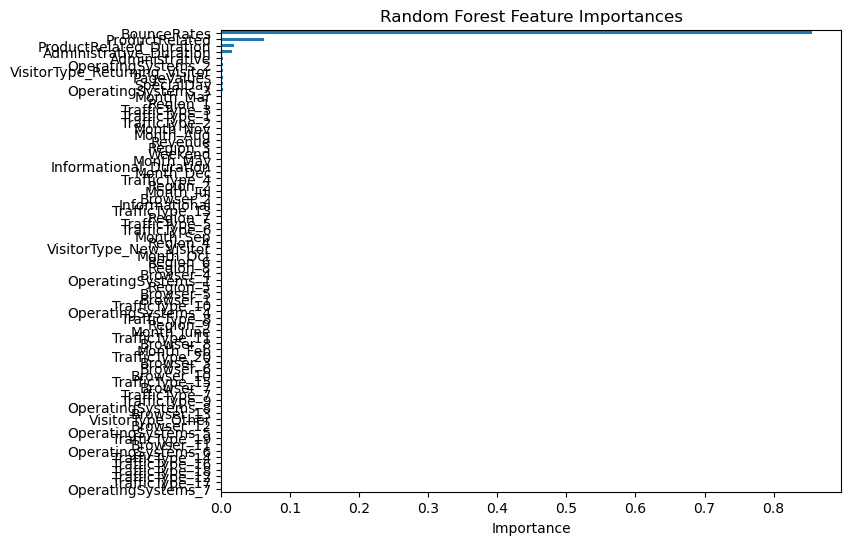

In [30]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import matplotlib.pyplot as plt

# Fit RF on your regression training data
rf = RandomForestRegressor(random_state=42)
rf.fit(X, y)

# Get importances paired with feature names
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

print(importances)

# Visualize
plt.figure(figsize=(8, 6))
importances.plot(kind='barh')
plt.title('Random Forest Feature Importances')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.show()

In [31]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestRegressor

results = {}

# Stop the kernel (interrupt/stop button), then reduce drastically:

param_grid = {
    "n_estimators": [100, 200],       # was [50, 150, 300]
    "max_depth": [10, None],           # was [10, 20, None]
    "min_samples_leaf": [1, 5],        # was [1, 2, 5]
    "max_features": ["sqrt"]           # was ["sqrt", 0.5]
}

grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=1  # let the outer loop handle parallelism
)

scores_rf = cross_val_score(
    grid_rf,
    X, y,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

results['RandomForest'] = (
    float((-scores_rf).mean().round(4)),   # flip sign back to positive MSE
    float(scores_rf.std().round(4))
)

print(results)

{'RandomForest': (0.0002, 0.0)}


In [32]:
results

{'RandomForest': (0.0002, 0.0)}

In [33]:
grid_rf.fit(X,y)
print(grid_rf.best_params_)
print(grid_rf.best_score_)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=1,
             param_grid={'max_depth': [10, None], 'max_features': ['sqrt'],
                         'min_samples_leaf': [1, 5],
                         'n_estimators': [100, 200]},
             scoring='neg_mean_squared_error')

{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 200}
-0.0001962682027002131


In [34]:
#building the random forest model with the best parameters
best_model = RandomForestRegressor(
    **grid_rf.best_params_, #selecting the best parameters
    random_state=42,
    n_jobs=-1
)

#fitting the model 
best_model.fit(X,y)

RandomForestRegressor(max_features='sqrt', n_estimators=200, n_jobs=-1,
                      random_state=42)

In [53]:
from sklearn.feature_selection import SelectFromModel

selector = SelectFromModel(rf, threshold='median', prefit=True)
X_reg_selected = selector.transform(X)

selected_features = X.columns[selector.get_support()]
print("Selected features:", list(selected_features))
list(selected_features)

Selected features: ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'PageValues', 'SpecialDay', 'Weekend', 'Revenue', 'OperatingSystems_2', 'OperatingSystems_3', 'Browser_2', 'Region_1', 'Region_2', 'Region_3', 'Region_4', 'Region_6', 'Region_7', 'TrafficType_1', 'TrafficType_2', 'TrafficType_3', 'TrafficType_4', 'TrafficType_5', 'TrafficType_6', 'TrafficType_13', 'VisitorType_New_Visitor', 'VisitorType_Returning_Visitor', 'Month_Aug', 'Month_Dec', 'Month_Jul', 'Month_Mar', 'Month_May', 'Month_Nov', 'Month_Oct', 'Month_Sep']


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


['Administrative',
 'Administrative_Duration',
 'Informational',
 'Informational_Duration',
 'ProductRelated',
 'ProductRelated_Duration',
 'BounceRates',
 'PageValues',
 'SpecialDay',
 'Weekend',
 'Revenue',
 'OperatingSystems_2',
 'OperatingSystems_3',
 'Browser_2',
 'Region_1',
 'Region_2',
 'Region_3',
 'Region_4',
 'Region_6',
 'Region_7',
 'TrafficType_1',
 'TrafficType_2',
 'TrafficType_3',
 'TrafficType_4',
 'TrafficType_5',
 'TrafficType_6',
 'TrafficType_13',
 'VisitorType_New_Visitor',
 'VisitorType_Returning_Visitor',
 'Month_Aug',
 'Month_Dec',
 'Month_Jul',
 'Month_Mar',
 'Month_May',
 'Month_Nov',
 'Month_Oct',
 'Month_Sep']

In [36]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

rf = RandomForestRegressor(random_state=42)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances)

RandomForestRegressor(random_state=42)

BounceRates                0.855235
ProductRelated             0.061792
ProductRelated_Duration    0.018606
Administrative_Duration    0.015800
Administrative             0.002801
                             ...   
TrafficType_16             0.000005
TrafficType_18             0.000003
TrafficType_12             0.000002
TrafficType_17             0.000001
OperatingSystems_7         0.000000
Length: 73, dtype: float64


### Lasso?

In [37]:
from sklearn.linear_model import LassoCV

lasso = LassoCV(cv=5, random_state=42).fit(X, y)
lasso_selected = X.columns[lasso.coef_ != 0]
print("Lasso selected:", list(lasso_selected))

Lasso selected: ['Administrative_Duration', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'PageValues']


Diagnostic plots?????

## Filling NAs 

In [38]:
# Use only the selected top features from your RF feature selection step
selected_features = list(selected_features)  # from before

X_reg_final = X[selected_features]
y_reg_final = y

final_model = RandomForestRegressor(random_state=42)
final_model.fit(X_reg_final, y_reg_final)

RandomForestRegressor(random_state=42)

In [40]:
# Do this ONCE, on the full df_train (before separating missing vs non-missing rows)
categorical_cols = ['OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Month']
df_train_encoded = pd.get_dummies(train_data, columns=categorical_cols)
df_test_encoded = pd.get_dummies(test_data, columns=categorical_cols)

test_NA = test_data.copy()
test_NA = pd.get_dummies(test_NA, columns=["OperatingSystems","Browser","Region","TrafficType","VisitorType","Month"])
test_NA["Revenue"] = test_NA["Revenue"].astype(int)
test_NA["Weekend"] = test_NA["Weekend"].astype(int)

# Align train/test columns too, in case some category only appears in one of them
df_train_encoded, df_test_encoded = df_train_encoded.align(df_test_encoded, join='left', axis=1, fill_value=0)

reg_data = train_NA[train_data['ExitRates'].notna()].copy()
missing_train = train_NA[train_NA['ExitRates'].isna()].copy()
missing_test = test_NA[test_NA['ExitRates'].isna()].copy()

X_reg = reg_data.drop(columns=['ExitRates', 'Revenue'])
y_reg = reg_data['ExitRates']

X_missing_train = missing_train[selected_features]
X_missing_test = missing_test[selected_features]

In [42]:
# Predict missing Exit Rate values
predicted_train = final_model.predict(X_missing_train)
predicted_test = final_model.predict(X_missing_test)

# Fill them back into the original dataframes
train_data.loc[train_data['ExitRates'].isna(), 'ExitRates'] = predicted_train
test_data.loc[test_data['ExitRates'].isna(), 'ExitRates'] = predicted_test

# Sanity check — no more missing values
print(train_data['ExitRates'].isna().sum())
print(test_data['ExitRates'].isna().sum())

0
0


In [43]:
print("Columns in missing_train:", missing_train.columns.tolist())
print()
print("Selected features:", selected_features)
print()
missing_cols = [f for f in selected_features if f not in missing_train.columns]
print("Selected features NOT in missing_train:", missing_cols)

Columns in missing_train: ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Weekend', 'Revenue', 'OperatingSystems_1', 'OperatingSystems_2', 'OperatingSystems_3', 'OperatingSystems_4', 'OperatingSystems_5', 'OperatingSystems_6', 'OperatingSystems_7', 'OperatingSystems_8', 'Browser_1', 'Browser_2', 'Browser_3', 'Browser_4', 'Browser_5', 'Browser_6', 'Browser_7', 'Browser_8', 'Browser_10', 'Browser_11', 'Browser_12', 'Browser_13', 'Region_1', 'Region_2', 'Region_3', 'Region_4', 'Region_5', 'Region_6', 'Region_7', 'Region_8', 'Region_9', 'TrafficType_1', 'TrafficType_2', 'TrafficType_3', 'TrafficType_4', 'TrafficType_5', 'TrafficType_6', 'TrafficType_7', 'TrafficType_8', 'TrafficType_9', 'TrafficType_10', 'TrafficType_11', 'TrafficType_12', 'TrafficType_13', 'TrafficType_14', 'TrafficType_15', 'TrafficType_16', 'TrafficType_17', 'TrafficType_18', 'Tr

---

# Task 2
_Use the regression model trained at the previous step to recover the Exit Rate by predicting its value for each missing sample on the train and test set. Build a classification model to predict whether an online shopper is likely to make a purchase. Perform feature selection, compare different algorithms, and identify the one that works the best on this dataset. Finally, test the best algorithm’s performance on the provided test set. Determine whether a model built using the Exit Rate information is better than a model built using the remaining features._

## Feature set

In [45]:
print(df_train_encoded['ExitRates'].isna().sum())
print(df_test_encoded['ExitRates'].isna().sum())
categorical_cols = ['OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Month']
df_train_encoded = pd.get_dummies(train_data, columns=categorical_cols)
df_test_encoded = pd.get_dummies(test_data, columns=categorical_cols)

2782
917


In [46]:
X_train_full = df_train_encoded.drop(columns=['Revenue'])
y_train_full = df_train_encoded['Revenue']

X_test_full = df_test_encoded.drop(columns=['Revenue'])
y_test_full = df_test_encoded['Revenue']

print(y_train_full.value_counts(normalize=True))  # reminder: check imbalance

Revenue
False    0.844183
True     0.155817
Name: proportion, dtype: float64


In [47]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate, StratifiedKFold
import pandas as pd

clf_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'LDA': LinearDiscriminantAnalysis(priors=[0.5, 0.5]),
    'QDA': QuadraticDiscriminantAnalysis(reg_param=0.1),
    'SVM': SVC(class_weight='balanced', probability=True),
    'Logistic Regression (L2)': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'Logistic Regression (L1)': LogisticRegression(penalty='l1', solver='liblinear', C=0.1, class_weight='balanced', max_iter=1000)
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

clf_results = {}

for name, model in clf_models.items():
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    
    scores = cross_validate(pipe, X_train_full, y_train_full, cv=skf, scoring=scoring)
    clf_results[name] = {metric: scores[f'test_{metric}'].mean() for metric in scoring}

clf_results_df = pd.DataFrame(clf_results).T
print(clf_results_df)

                          accuracy  precision    recall        f1   roc_auc
Logistic Regression       0.841479   0.494322  0.752953  0.596807  0.897600
LDA                       0.875974   0.600016  0.615537  0.607361  0.893576
QDA                       0.376948   0.193115  0.943096  0.320570  0.772958
SVM                       0.844724   0.501305  0.714067  0.588979  0.882859
Logistic Regression (L2)  0.841479   0.494322  0.752953  0.596807  0.897600
Logistic Regression (L1)  0.844399   0.500531  0.753645  0.601511  0.901239


## Feature selection!

In [49]:
rf_clf = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_clf.fit(X_train_full, y_train_full)

importances_clf = pd.Series(rf_clf.feature_importances_, index=X_train_full.columns).sort_values(ascending=False)
print(importances_clf)

selector = SelectFromModel(rf_clf, threshold='median', prefit=True)
X_reg_selected = selector.transform(X_train_full)

selected_features = X_train_full.columns[selector.get_support()]
print("Selected features:", list(selected_features))

RandomForestClassifier(class_weight='balanced', random_state=42)

PageValues                 3.251127e-01
ExitRates                  9.740665e-02
ProductRelated_Duration    8.053958e-02
ProductRelated             6.822243e-02
BounceRates                5.441932e-02
                               ...     
TrafficType_18             8.399498e-06
TrafficType_16             1.508421e-06
TrafficType_12             4.740904e-07
OperatingSystems_7         3.879278e-20
TrafficType_17             0.000000e+00
Length: 73, dtype: float64
Selected features: ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Weekend', 'OperatingSystems_1', 'OperatingSystems_2', 'OperatingSystems_3', 'Browser_1', 'Browser_2', 'Browser_4', 'Region_1', 'Region_2', 'Region_3', 'Region_4', 'Region_6', 'TrafficType_1', 'TrafficType_2', 'TrafficType_3', 'TrafficType_4', 'TrafficType_8', 'VisitorType_New_Visitor', 'VisitorType_Returning_Visitor', 'Mo

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


## Performance on test set

In [50]:
best_model = RandomForestClassifier(random_state=42, class_weight='balanced')  # example — use whichever won
best_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', best_model)
])

best_pipe.fit(X_train_full[selected_features], y_train_full)

from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

y_pred = best_pipe.predict(X_test_full[selected_features])

y_proba = best_pipe.predict_proba(X_test_full[selected_features])[:, 1]

print(classification_report(y_test_full, y_pred))
print("ROC-AUC:", roc_auc_score(y_test_full, y_proba))
print(confusion_matrix(y_test_full, y_pred))

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=42))])

              precision    recall  f1-score   support

       False       0.92      0.97      0.95      2615
        True       0.77      0.56      0.65       467

    accuracy                           0.91      3082
   macro avg       0.85      0.76      0.80      3082
weighted avg       0.90      0.91      0.90      3082

ROC-AUC: 0.9298410176833537
[[2539   76]
 [ 207  260]]


### No exit rate

In [51]:
X_train_no_exit = df_train_encoded.drop(columns=['ExitRates'])
y_train_no_exit = df_train_encoded['ExitRates']

X_test_no_exit = df_test_encoded.drop(columns=['ExitRates'])
y_test_no_exit = df_test_encoded['ExitRates']

# Repeat Step 3's CV comparison and Step 5's test evaluation using X_train_no_exit / X_test_no_exit
# Then put the two result tables side by side and compare metrics directly

---

# Task 3 
_Repeat the analysis done at step 2 with clustering-based algorithms; com- pare the performance with respect to the best classification model_